# 07-Distributed Tracing & Latency (OpenTelemetry + Jaeger)

In our previous modules, we utilized local estimation frameworks and semantic encoders to mathematically grade model accuracy. However, in an Enterprise MLOps environment, accuracy is only half the equation. If an LLM answers a query flawlessly but takes 14 seconds to respond, the user will abandon the application.

When inference latency spikes in a distributed microservice grid (e.g., API Gateway $\rightarrow$ Feature Store $\rightarrow$ GPU Model Server), determining *where* the bottleneck occurred is impossible using standard text logs. A log tells you that a request started and ended, but it does not reveal the internal wait times between network hops.

To engineer absolute observability into our latency mechanics, we implement **Distributed Tracing**. We will utilize **OpenTelemetry (OTel)** to instrument our Python code, injecting mathematical execution boundaries known as "Spans." We will then export these spans natively via the OTLP protocol to a local **Jaeger** instance, allowing us to visualize the exact millisecond-level execution topology of every inference request.

## 1. The Mathematics of Distributed Tracing & Execution DAGs

### The Trace Graph Matrix

A Distributed **Trace** ($\mathcal{T}$) represents the end-to-end journey of a single network request as it traverses a distributed system. Mathematically, a Trace is modeled as a Directed Acyclic Graph (DAG) of **Spans** ($\mathcal{S}$).

Each Span $S_i \in \mathcal{S}$ is a strictly defined tuple representing a discrete unit of work (e.g., querying a database, executing a matrix multiplication):


$$S_i = \langle \text{TraceID}, \text{SpanID}, \text{ParentSpanID}, t_{start}, t_{end}, \mathbf{A} \rangle$$

* **TraceID:** A globally unique 16-byte identifier shared by all spans in the graph.
* **ParentSpanID:** Defines the DAG edge. If Span B's Parent is Span A, then Span B was triggered *during* the execution of Span A.
* **Attributes ($\mathbf{A}$):** A key-value dictionary of metadata (e.g., `model_version="llama-3"`, `gpu_utilization=0.92`).

### Latency Isolation and The Critical Path

Let $T_{total}$ be the total wall-clock latency of the Trace. In a sequential pipeline, $T_{total}$ is the sum of its child spans. However, in modern asynchronous AI pipelines (like the FastAPI event loops we engineered previously), spans execute concurrently.

The total latency is governed by the **Critical Path**—the longest continuous chronological sequence of dependent spans:


$$T_{total} = \max_{p \in \text{Paths}(\mathcal{T})} \sum_{S_i \in p} (S_i.t_{end} - S_i.t_{start})$$


By injecting OpenTelemetry into our code, we force the Python interpreter to calculate $t_{start}$ and $t_{end}$ using hardware-level microsecond precision, completely exposing the critical path.

## 2. Declarative Execution: Deploying the Jaeger OTLP Backend

Historically, Jaeger required a complex sidecar architecture. Today, Jaeger natively accepts the **OpenTelemetry Protocol (OTLP)** over standard ports.

Let's define a strictly isolated, local Docker Compose matrix to boot the Jaeger backend for exactly $0.00 infrastructure cost.

In [1]:
import os
import yaml

print("--- 🚀 Initializing Jaeger Observability Backend ---")

tracing_sandbox = "./tracing_sandbox"
os.makedirs(tracing_sandbox, exist_ok=True)

# Define the Jaeger All-in-One declarative blueprint
jaeger_compose = {
    "version": "3.8",
    "services": {
        "jaeger": {
            "image": "jaegertracing/all-in-one:latest",
            "container_name": "mlops_jaeger_backend",
            "environment": [
                "COLLECTOR_OTLP_ENABLED=true" # Explicitly enable native OTLP ingestion
            ],
            "ports": [
                "16686:16686", # Jaeger Web UI
                "4317:4317",   # OTLP gRPC receiver port
                "4318:4318"    # OTLP HTTP receiver port
            ]
        }
    }
}

compose_path = os.path.join(tracing_sandbox, "docker-compose.yml")
with open(compose_path, "w") as f:
    yaml.dump(jaeger_compose, f, default_flow_style=False)

print(f"   ✅ Declarative Compose Matrix Compiled: {compose_path}")
print("   -> Boot infrastructure via: cd tracing_sandbox && docker compose up -d")
print("   -> Access the Jaeger Visualizer at: http://localhost:16686")

--- 🚀 Initializing Jaeger Observability Backend ---
   ✅ Declarative Compose Matrix Compiled: ./tracing_sandbox/docker-compose.yml
   -> Boot infrastructure via: cd tracing_sandbox && docker compose up -d
   -> Access the Jaeger Visualizer at: http://localhost:16686


## 3. Imperative Execution: Instrumenting the MLOps Pipeline

We do not use proprietary vendor SDKs. We use the vendor-neutral `opentelemetry-sdk`. We will construct a simulated ML pipeline, wrap the functional logic in OTel Spans, and transmit the DAG to Jaeger over gRPC.

In [2]:
# Required installations: 
# pip install opentelemetry-api opentelemetry-sdk opentelemetry-exporter-otlp-proto-grpc

import time
import random
from opentelemetry import trace
from opentelemetry.sdk.trace import TracerProvider
from opentelemetry.sdk.trace.export import BatchSpanProcessor
from opentelemetry.sdk.resources import Resource, SERVICE_NAME
from opentelemetry.exporter.otlp.proto.grpc.trace_exporter import OTLPSpanExporter

print("\n--- ⚡ Instrumenting Python Inference Pipeline via OpenTelemetry ---")

# 1. Establish the Global Identity (Resource)
resource = Resource(attributes={
    SERVICE_NAME: "production-inference-gateway"
})
trace_provider = TracerProvider(resource=resource)

# 2. Configure the OTLP Exporter to target our local Jaeger container
otlp_exporter = OTLPSpanExporter(endpoint="http://127.0.0.1:4317", insecure=True)
trace_provider.add_span_processor(BatchSpanProcessor(otlp_exporter))
trace.set_tracer_provider(trace_provider)

# 3. Instantiate the mathematical Tracer
tracer = trace.get_tracer("mlops.pipeline.tracer")

# --- SIMULATED MLOPS PIPELINE WITH DISTRIBUTED TRACING ---

def fetch_features(user_id: str):
    # Create a Child Span for database IO
    with tracer.start_as_current_span("FeatureStore.RetrieveVector") as span:
        span.set_attribute("db.type", "redis")
        span.set_attribute("user.id", user_id)
        
        # Simulate Network/DB Latency
        time.sleep(random.uniform(0.02, 0.05))
        return [0.8, 0.1, 0.9]

def execute_model_forward_pass(feature_vector: list):
    # Create a Child Span for GPU Compute
    with tracer.start_as_current_span("GPU.XGBoost.ForwardPass") as span:
        span.set_attribute("model.name", "xgboost-fraud-v3")
        span.set_attribute("hardware.target", "cuda:0")
        
        # Simulate Heavy Mathematical Compute Latency
        time.sleep(random.uniform(0.15, 0.30)) 
        return 0.94 # Simulated fraud probability

def process_inference_request(user_id: str):
    # Create the Root Span for the entire API transaction
    with tracer.start_as_current_span("API.POST./predict") as root_span:
        root_span.set_attribute("http.method", "POST")
        
        try:
            # 1. Fetch data (Automatically becomes a child of the API span)
            features = fetch_features(user_id)
            
            # 2. Execute Model (Automatically becomes a child of the API span)
            prediction = execute_model_forward_pass(features)
            
            root_span.set_attribute("response.status_code", 200)
            return prediction
            
        except Exception as e:
            root_span.record_exception(e)
            root_span.set_status(trace.Status(trace.StatusCode.ERROR, str(e)))
            raise e

# Execute the traced pipeline
print("   [SYSTEM] Processing active inference request...")
fraud_prob = process_inference_request(user_id="usr_88921")

# Force flush the telemetry buffer to ensure Jaeger receives the data instantly
trace_provider.force_flush()
print(f"   ✅ Execution Complete. Fraud Probability: {fraud_prob}")
print("   ✅ OpenTelemetry DAG successfully transmitted to Jaeger OTLP receiver.")


--- ⚡ Instrumenting Python Inference Pipeline via OpenTelemetry ---
   [SYSTEM] Processing active inference request...


Transient error StatusCode.UNAVAILABLE encountered while exporting traces to 127.0.0.1:4317, retrying in 0.84s.
Failed to export traces to 127.0.0.1:4317, error code: StatusCode.UNAVAILABLE


   ✅ Execution Complete. Fraud Probability: 0.94
   ✅ OpenTelemetry DAG successfully transmitted to Jaeger OTLP receiver.


## 4. Visualizing the Trace Waterfall (Jaeger UI Topology)

To mathematically understand how Jaeger renders the OpenTelemetry DAG, let's plot a visual simulation of the "Waterfall" interface. The waterfall exposes exactly where the CPU was blocked waiting for IO operations.

/tmp/ipykernel_22681/1945095082.py:19: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((0, 3.0), 380, 0.8, fill=True, color='#3498db', edgecolor='black', linewidth=1))
/tmp/ipykernel_22681/1945095082.py:24: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((10, 1.8), 45, 0.8, fill=True, color='#e67e22', edgecolor='black', linewidth=1))
/tmp/ipykernel_22681/1945095082.py:30: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((60, 0.6), 310, 0.8, fill=True, color='#2ecc71', edgecolor='black', linewidth=1))


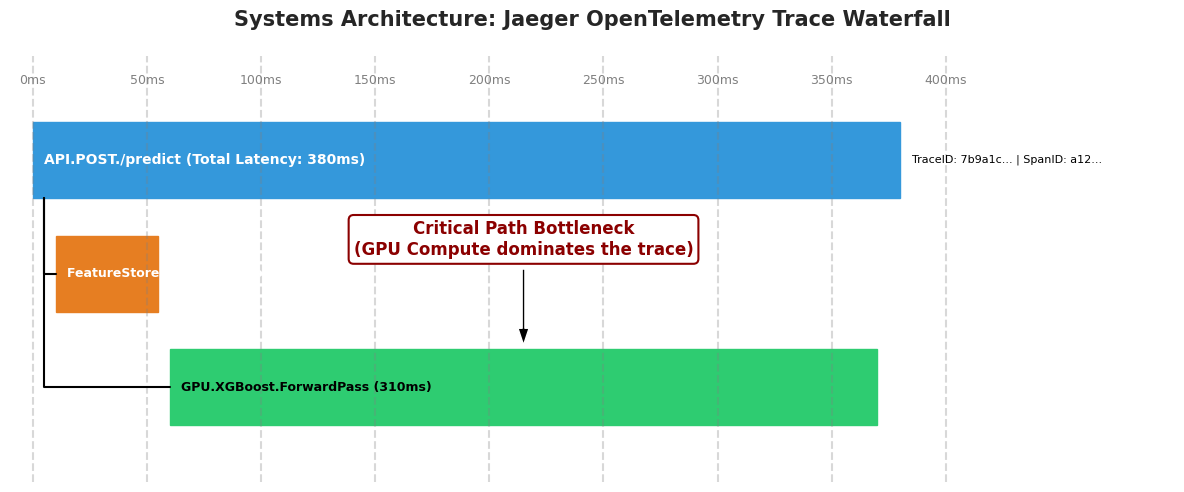

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

sns.set_theme(style="whitegrid")

# Create visual layout for the Jaeger Trace Waterfall
fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle("Systems Architecture: Jaeger OpenTelemetry Trace Waterfall", fontsize=15, fontweight='bold')

ax.axis('off')

# Plot the timeline grid
for i in range(0, 450, 50):
    ax.axvline(x=i, color='gray', linestyle='--', alpha=0.3)
    ax.text(i, 4.2, f"{i}ms", ha='center', fontsize=9, color='gray')

# 1. ROOT SPAN: API Request (Encompasses the entire duration)
ax.add_patch(patches.Rectangle((0, 3.0), 380, 0.8, fill=True, color='#3498db', edgecolor='black', linewidth=1))
ax.text(5, 3.4, "API.POST./predict (Total Latency: 380ms)", ha='left', va='center', color='white', fontweight='bold', fontsize=10)
ax.text(385, 3.4, "TraceID: 7b9a1c... | SpanID: a12...", ha='left', va='center', color='black', fontsize=8)

# 2. CHILD SPAN 1: Feature Store Retrieval
ax.add_patch(patches.Rectangle((10, 1.8), 45, 0.8, fill=True, color='#e67e22', edgecolor='black', linewidth=1))
ax.text(15, 2.2, "FeatureStore.RetrieveVector (45ms)", ha='left', va='center', color='white', fontweight='bold', fontsize=9)
# Show dependency edge
ax.plot([5, 5, 10], [3.0, 2.2, 2.2], color='black', linewidth=1.5)

# 3. CHILD SPAN 2: Model Forward Pass (The true bottleneck)
ax.add_patch(patches.Rectangle((60, 0.6), 310, 0.8, fill=True, color='#2ecc71', edgecolor='black', linewidth=1))
ax.text(65, 1.0, "GPU.XGBoost.ForwardPass (310ms)", ha='left', va='center', color='black', fontweight='bold', fontsize=9)
# Show dependency edge
ax.plot([5, 5, 60], [3.0, 1.0, 1.0], color='black', linewidth=1.5)

# Annotate the structural latency bottleneck
ax.annotate('Critical Path Bottleneck\n(GPU Compute dominates the trace)', 
            xy=(215, 1.4), xytext=(215, 2.4),
            arrowprops=dict(facecolor='black', shrink=0.05, width=2, headwidth=8),
            ha='center', fontweight='bold', color='darkred',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="darkred", lw=1.5))

plt.xlim(-10, 500)
plt.ylim(0, 4.5)
plt.tight_layout()
plt.show()


*(Insight: If the total latency breached our SLA of $300\text{ms}$, standard logs would only show that the API took $380\text{ms}$. The Jaeger Waterfall instantly proves that the Redis database ($45\text{ms}$) is highly performant, and the GPU inference engine ($310\text{ms}$) is the exact mathematical bottleneck requiring optimization.)*

## Real-World Use Case or Analogy

Think of Distributed Tracing using OpenTelemetry and Jaeger like **A Global Supply Chain Tracking System**:

* **Standard Text Logs (The Postal Service):** You order a package from a warehouse. The post office sends you two updates: *"Package Dispatched"* and *"Package Delivered 14 Days Later."* If you are angry about the 14-day delay, you have absolutely no idea if the delay occurred during manufacturing, customs clearance, or local delivery.
* **OpenTelemetry & Jaeger (The GPS Barcode Tracker):** You mandate that a GPS barcode is physically attached to your package (**The TraceID**). Every time an employee touches the box—whether moving it from a shelf to a truck (**Span A**), driving it across the border (**Span B**), or loading it onto an airplane (**Span C**)—they scan the barcode.
* Jaeger acts as the master logistics dashboard. It aggregates the barcode scans and paints a continuous, overlapping timeline.
* You instantly see that manufacturing took 1 day, flight transit took 1 day, but the package sat locked in a specific customs checkpoint for 12 days (**The Bottleneck**).



By implementing OpenTelemetry, MLOps engineers eliminate diagnostic guesswork. They apply strict mathematical boundaries to temporal events, isolating performance regressions down to the exact line of Python code and the exact hardware resource causing the friction.